<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-5 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Convolution Neural Networks </h2> </html>

<html> <h2 style="font-style:italic; color:blue;"> Task 1 : </h2> </html>

#### Develop and evaluate an image classifier using Convolution Neural Network.

### The Data = CIFAR 10, Multiple Classes datset.

CIFAR-10 is a dataset of 50,000 32x32 color training images, labeled over 10 categories, and 10,000 test images.

ttps://www.cs.toronto.edu/~kriz/cifar.html

Example of using Keras for CNNs. Use a famous data set, the CIFAR-10 dataset which consists of 10 different image types.

![image.png](attachment:image.png)

In [1]:
# Your code to import matplotlib, pandas and numpy libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

##### Following code loads the CIFAR 10 datset.

In [2]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
# Your code to print shapes of training and test data. Check how the data looks

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [4]:
# Your code to print shapes of training and test data. Check how the data looks

x_train[0].shape

(32, 32, 3)

### RGB Colour Model)

![image-2.png](attachment:image-2.png)

![image.png](attachment:image.png)

![image.png](attachment:image.png)

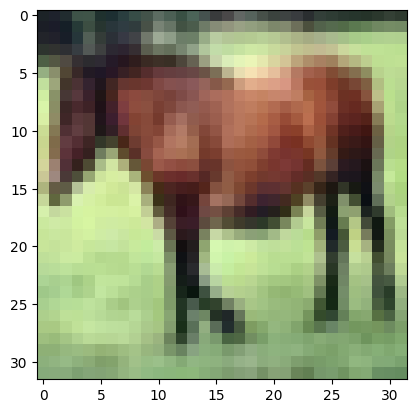

In [5]:
# Your code to show any sample image in the dataset. Use - plt.imshow()

# HORSE
plt.imshow(x_train[7]);

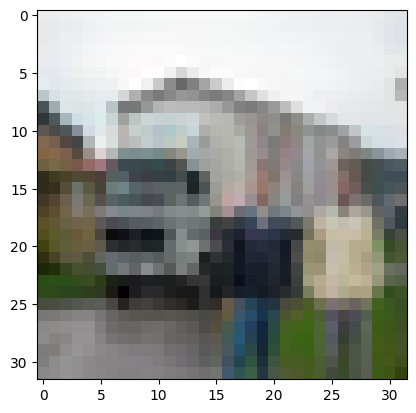

In [6]:
# Show any other image

# TRUCK
plt.imshow(x_train[16]);

In [7]:
# Class names in the CIFAR-10 dataset

classes=['aircraft', 'car', 'bird', 'cat', 'deer',
'dog', 'frog', 'horse', 'ship', 'truck']

classes

['aircraft',
 'car',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

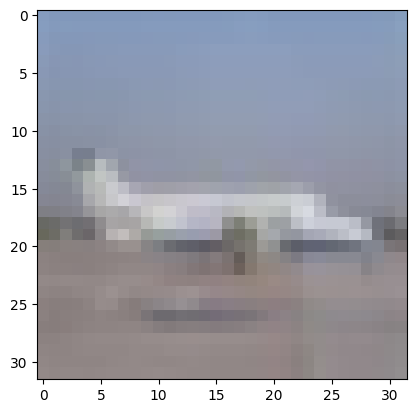

Picture number in the DataBase: 8437
Class number: [0]
Class name: aircraft


In [8]:
# Random Demo example from database

import random # random number generator

from PIL import Image


n = random.randint(0, x_test.shape[0])

# Image.fromarray - for drawing an image from CIFAR-10

plt.imshow(Image.fromarray(x_train[n]))
plt.show()

print("Picture number in the DataBase:", n)
print("Class number:", y_train[n])
print("Class name:", classes[y_train[n][0]])


# You can run this cell many times, and you will get a new picture each time.


## PreProcessing

In [9]:
# Your code to print one image in digitals. Check what pixels look like.

print(x_train[0])

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


In [10]:
# Your code to print the shape of any image i.e particular value in the x_train

x_train[0].shape


(32, 32, 3)

In [11]:
# Your code to print the maximum value in x_train. Hint - Use .max()

x_train.max()

np.uint8(255)

In [12]:
# Normalisation

x_train = x_train/255
x_test = x_test/255

# Run this code only once!

In [13]:
x_train.max()

np.float64(1.0)

In [14]:
# Print the shape of x_train again.

x_train.shape


(50000, 32, 32, 3)

In [15]:
# Print the shape of y_train again

y_train.shape


(50000, 1)

## One hot vector encoding.
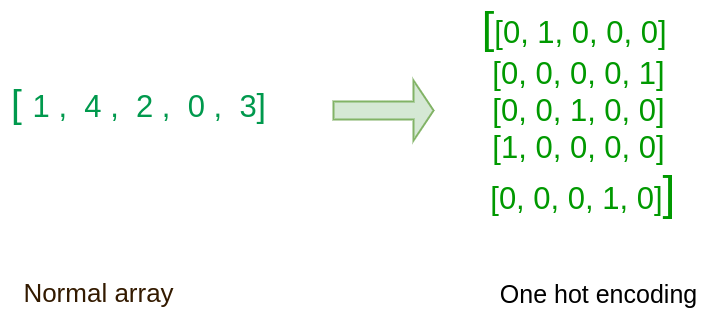


The "to_categorical()" is converting the integer value to binary categorical matrix : https://keras.io/api/utils/python_utils/#to_categorical-functionLinks to an external site.

In [16]:
from tensorflow.keras.utils import to_categorical


In [17]:
# Print shape of y_train [0]

print(y_train[0].shape)

(1,)


In [18]:
# code to use to_categorical to convert integers to numbers.
# Assign the new array to the variable y_cat_train

y_cat_train = to_categorical(y_train,10)

In [19]:
# Your code to print the shape of the array y_cat_train

y_cat_train.shape

(50000, 10)

In [20]:
# Your code to print any single value in the array y_cat_train and print y_train with the same index.

# Compare the result for better understanding of "to_categorical()"

print(y_train[0])


print(y_cat_train[0])

[6]
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [21]:
# Convert y_test to the encoded vector in the same manner
# Assign it to the variable y_cat_test

y_cat_test = to_categorical(y_test,10)

In [22]:
# print the shapes to show how y_cat_test looks

print(y_cat_test.shape)

print(y_test[0])
print(y_cat_test[0])

(10000, 10)
[3]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


----------

## Creating a CNN Model

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten

#### Please read the following links before creating code for the next cell

https://keras.io/api/layers/convolution_layers/convolution2d/
    
https://keras.io/api/layers/pooling_layers/max_pooling2d/

In [24]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(4,4),input_shape=(32, 32, 3), activation='relu',))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(filters=64, kernel_size=(4,4), activation='relu',))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
# Here, you must receive your own CNN architecture

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 446,826 (1.70 MB)

 Trainable params: 446,826 (1.70 MB)

 Non-trainable params: 0 (0.00 B)

### We could use early stopping in Keras to break from the training.
### What this does is for successive iterations it monitors the loss. If the loss does not decreases for a certain number of iterations denoted by variable 'patience' then the training stops.
### Following code shows how you can use early stopping.


In [26]:
from tensorflow.keras.callbacks import EarlyStopping

In [27]:
early_stop = EarlyStopping(monitor='val_loss',patience=4)

In [28]:
#EarlyStopping?

In [29]:
# compile the models (model.compile). Use 'categorical cross entropy' as the loss function
# and use 'accuracy' as the metrics
# Your can use the optimiser of your choice

model.compile(loss='categorical_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [30]:
YOUR_LAST_SID_DIGITAL = 1

# Fit the model (model.fit).

# Use additional parameter -  callbacks = [early_stop] to enable early stopping.
# Use 'history' array to save the training parameters for each epoch

history = model.fit( x_train, y_cat_train,
                # the number of times of training using the whole dataset
                    epochs=YOUR_LAST_SID_DIGITAL+10,

                    validation_data =(x_test,y_cat_test),

                # Boolean (whether to shuffle the training data before each epoch)
                # Default parameter - you don’t have to write
                    shuffle = True,

                # 1 = progress bar printing
                    verbose = 1,

                # early stopping
                    callbacks=[early_stop] )



Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 54ms/step - accuracy: 0.4623 - loss: 1.4915 - val_accuracy: 0.5839 - val_loss: 1.1835
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 53ms/step - accuracy: 0.6095 - loss: 1.1110 - val_accuracy: 0.6087 - val_loss: 1.0998
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 52ms/step - accuracy: 0.6726 - loss: 0.9439 - val_accuracy: 0.6566 - val_loss: 0.9989
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 55ms/step - accuracy: 0.7167 - loss: 0.8254 - val_accuracy: 0.6586 - val_loss: 0.9983
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.7496 - loss: 0.7315 - val_accuracy: 0.6494 - val_loss: 1.0886
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.7787 - loss: 0.6591 - val_accuracy: 0.6743 - val_loss: 1.0732
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.7983 - loss: 0.5992 - val_accuracy: 0.6800 - val_loss: 1.0847
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.8178

In [31]:
# You can save the model in a file. Following code shows how to do this
# Careful, don't overwrite file!

model.save('cifar_10epochs.keras')

##### You can save the loss at every step. Following code shows how to do this.

In [32]:
losses = pd.DataFrame(model.history.history)

In [33]:
# You code to print the first few rows of losses.

losses.head(8)

,accuracy,loss,val_accuracy,val_loss
0,0.46234,1.491471,0.5839,1.183511
1,0.60950,1.110958,0.6087,1.099794
2,0.67262,0.943867,0.6566,0.998935
3,0.71666,0.825433,0.6586,0.998320
4,0.74960,0.731550,0.6494,1.088617
5,0.77866,0.659106,0.6743,1.073155
6,0.79830,0.599248,0.6800,1.084672
7,0.81782,0.545571,0.6519,1.218484


### Visualise a plot between accuracy vs val_accuracy for all steps.

### x axis will have the steps (epochs)
### y axis will have accuracy and val_accuracy





<Axes: >

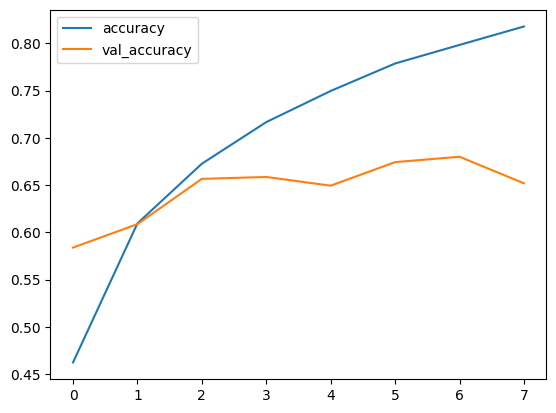

In [34]:
# plot accuracy and val_accuracy vs the epochs

losses[['accuracy','val_accuracy']].plot()

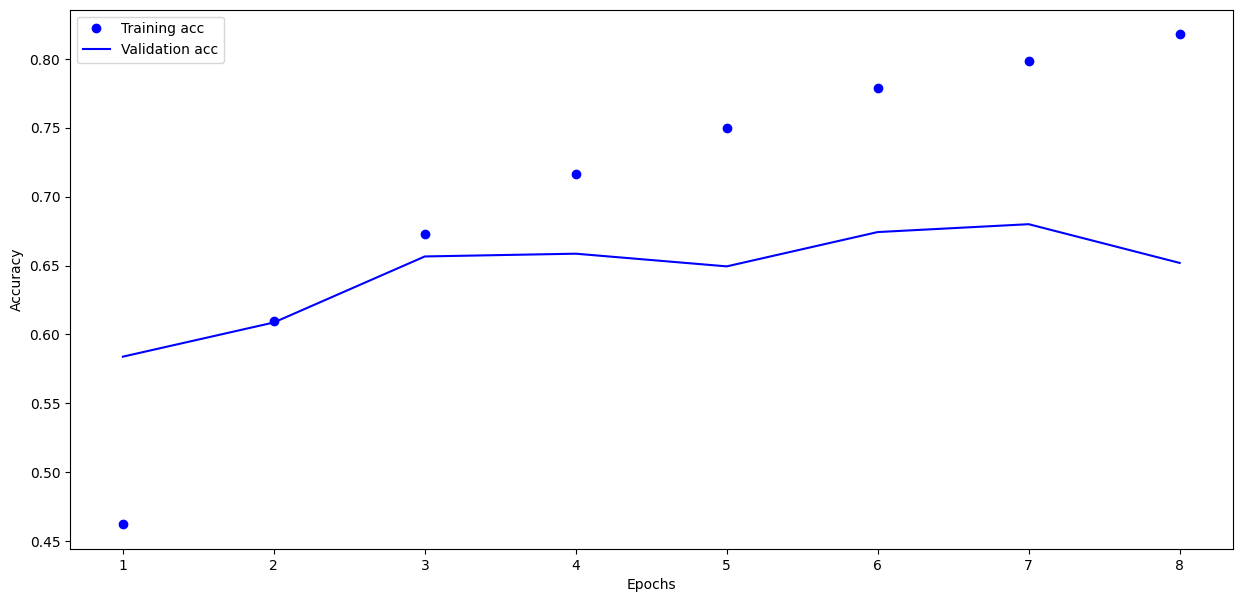

In [35]:
# Plot accuracy and val_accuracy for the neural network training process in more detail

history_dict = history.history
#plt.style.use('seaborn-darkgrid')

acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

<Axes: >

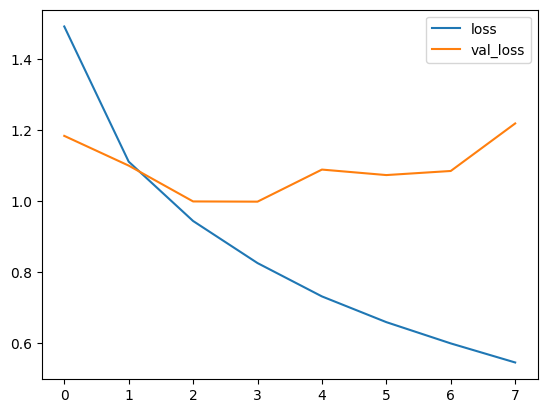

In [36]:
# plot loss and val_loss vs the epochs

losses[['loss','val_loss']].plot()

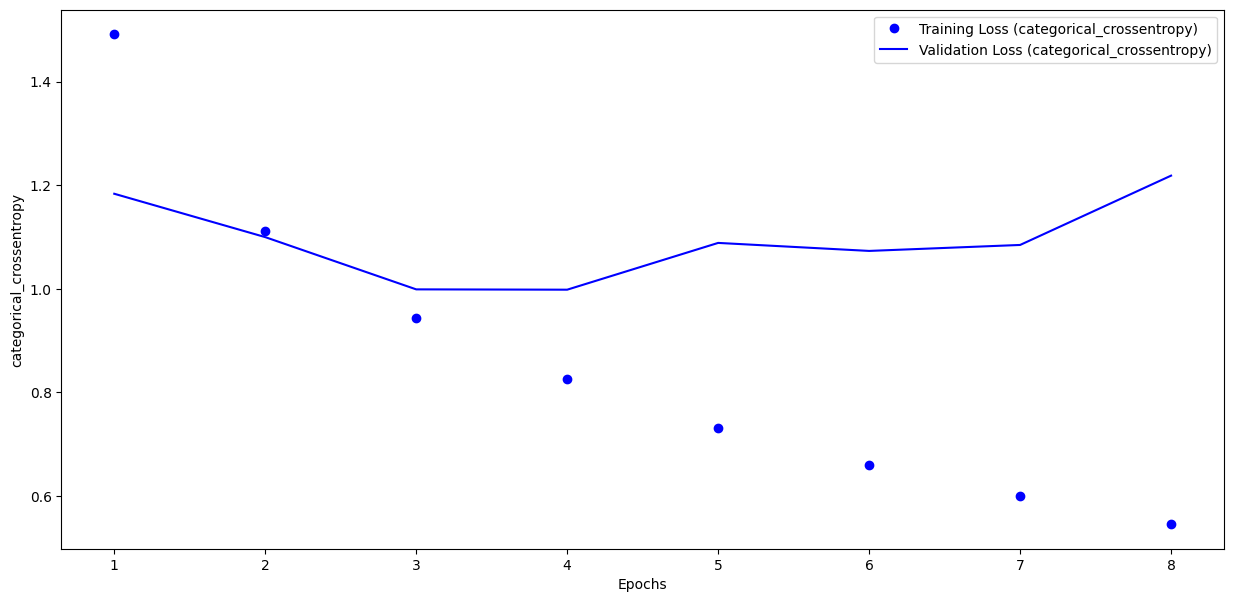

In [37]:
# Printing Loss function (categorical_crossentropy) for the neural network training process in more detail

history_dict = history.history
#plt.style.use('seaborn-darkgrid')

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training Loss (categorical_crossentropy)')
plt.plot(epochs, val_acc_values, 'b', label='Validation Loss (categorical_crossentropy)')
plt.xlabel('Epochs')
plt.ylabel('categorical_crossentropy')
plt.legend()

plt.show()

In [38]:
# Print the metrics' names that model has used

model.metrics_names

['loss', 'compile_metrics']

In [39]:
# Evaluate the model

model.evaluate(x_test,y_cat_test,verbose=0)

[1.2184842824935913, 0.6518999934196472]

### Make a prediction on test data set.   

In [40]:
# Make a prediction on the test data set

predictions_prob = model.predict(x_test)
predictions = predictions_prob.argmax(axis = -1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [41]:
# make predictions on the test dataset.
# Store the prediction in variable 'predicrion'. Hint - Use model.predict()

#prediction = np.argmax(model.predict(x_test), axis = -1)

In [42]:
#np.argmax?

In [43]:
print(predictions)
print(predictions.shape)

[3 8 9 ... 5 4 7]
(10000,)


##### You could get the full classification report.


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.87      0.49      0.62      1000
           1       0.82      0.74      0.78      1000
           2       0.70      0.43      0.53      1000
           3       0.41      0.57      0.48      1000
           4       0.65      0.58      0.61      1000
           5       0.50      0.66      0.57      1000
           6       0.75      0.76      0.75      1000
           7       0.81      0.63      0.71      1000
           8       0.75      0.78      0.76      1000
           9       0.61      0.89      0.72      1000

    accuracy                           0.65     10000
   macro avg       0.68      0.65      0.65     10000
weighted avg       0.68      0.65      0.65     10000



##### You could also get and plot confusion matrix.

https://github.com/matplotlib/matplotlib/issues/14751

In [45]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,predictions)

array([[487,  27,  54,  86,  52,  21,  16,   7, 141, 109],
       [  5, 745,   3,   7,   4,  11,   9,   1,  24, 191],
       [ 26,  13, 429, 161,  84, 152,  59,  20,  23,  33],
       [  4,  13,  23, 572,  52, 207,  54,  22,  11,  42],
       [  7,   8,  39, 127, 576,  87,  73,  51,  13,  19],
       [  4,   4,  19, 194,  29, 660,  28,  30,   9,  23],
       [  2,   7,  15, 115,  19,  41, 760,   6,   5,  30],
       [  6,   9,  13,  87,  66, 124,  16, 627,  12,  40],
       [ 16,  35,  16,  42,  10,  13,   3,   2, 778,  85],
       [  6,  53,   6,  15,   1,   4,   1,   5,  24, 885]])

<Axes: >

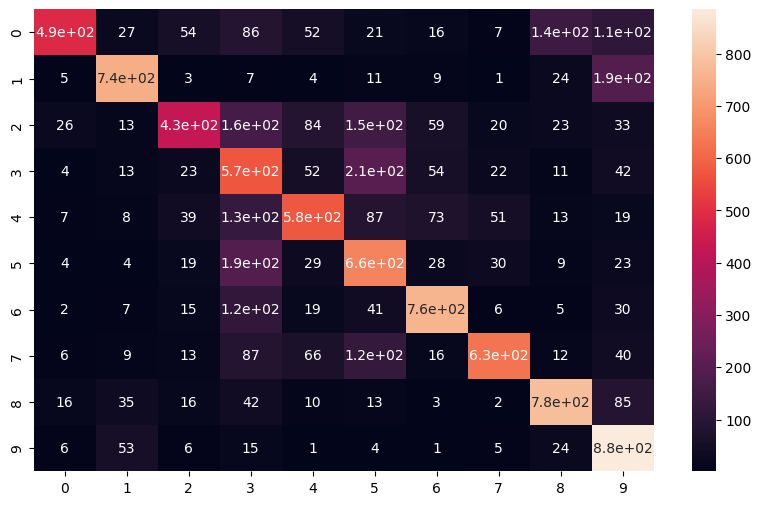

In [46]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test,predictions),annot=True)


### Following code makes a prediction on specific image.

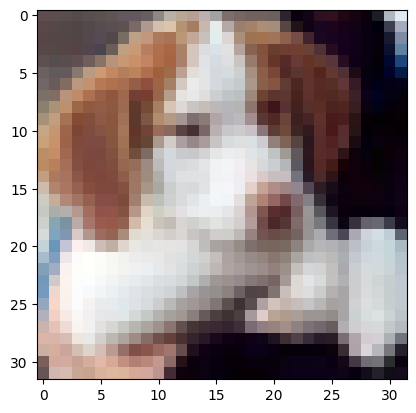

In [47]:
my_image = x_test[16]

plt.imshow(my_image);

In [48]:
# SHAPE --> (num_images,width,height,color_channels)

model.predict(my_image.reshape(1,32,32,3))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


array([[2.0388886e-04, 6.1857615e-02, 4.3772245e-03, 3.9433174e-02,
        1.2178377e-05, 7.4084264e-01, 2.5304529e-05, 1.0329738e-02,
        5.5204926e-04, 1.4236610e-01]], dtype=float32)

In [49]:
# Find the highest probability value in the vector above.
# What output value does it point to?

In [50]:
prediction = np.argmax(model.predict(my_image.reshape(1,32,32,3)), axis = -1)
print(prediction)
print("Class name:", classes[prediction[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
[5]
Class name: dog


### Let's use a trained neural network
You can run the following code many times

Note the recognition probabilities for each image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


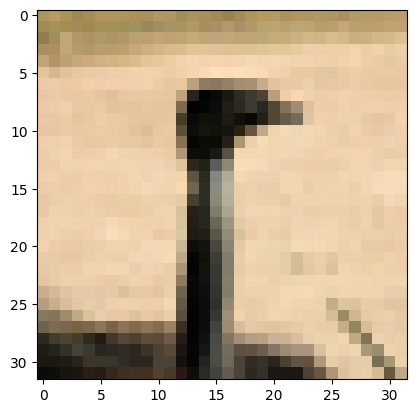

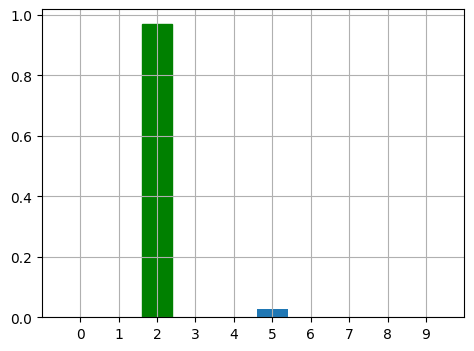

The predicted answer: bird 
 Correct answer: bird
['aircraft', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [51]:
from tensorflow.keras.preprocessing.image import array_to_img

# we take a random element 'random.randint()' from the test sample
# and observe: the neural network will guess or not
index = random.randint(0, x_test.shape[0])
plt.imshow(array_to_img(x_test[index]))

# test image conversion
x = x_test[index]
x = np.expand_dims(x, axis=0)

# start recognition
prediction = model.predict(x)
sample = x

# converting the result from one hot encoding format
ans = np.argmax(prediction)

fig = plt.figure(figsize=(12,4))

ax = fig.add_subplot(1, 2, 2)
bar_list = ax.bar(np.arange(10), prediction[0], align='center')
bar_list[ans].set_color('g')
ax.set_xticks(np.arange(10))
ax.set_xlim([-1, 10])
ax.grid('on')

plt.show()

print('The predicted answer: {}'.format((classes[ans])), "\n",
     'Correct answer: {}'.format(classes[y_test[index][0]]) )

print(classes)


# You can run this cell many times, and each time you will get a new picture,
# which this neural network will recognise with the probability indicated on the graph.

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Plot of the model building code and model's summary

### 2. Please ensure to document in your laboratory logbook a graphical representation depicting the train loss and validation loss trends (4 graphs).

### 3. Based on this analysis, determine the optimal number of epochs for training your model.

<html> <h2 style="font-style:italic; color:blue;"> Task 2 (Optional): </h2> </html>

#### Evaluate your model for different optimisers available in the Keras.

https://keras.io/api/optimizers/

- Store the optimisers in an array.
- Use for loop to fit, compile, and  test your model.
- Plot the accuracy vs optimiser


In [52]:
# Create a list containing the names of optimisers (Don't use 'AdamW' and 'Adafactor')
# Create an empty list to store scores

# For every optimiser
   # compile your model
   # fit your model, use epochs=3 for each optimiser (otherwise the training will take a long time)
   # using model.evaluate() find score and append the score in a list

# Plot score vs optimiser

In [53]:
optimizers = ['Nadam', 'SGD', 'RMSprop', 'Adam', 'Adadelta', 'Adagrad', 'Adamax']
scores = []

In [54]:
from tensorflow.keras import models

In [ ]:
for row in optimizers:
    #model_1 = models.load_model('Conv_mod')
    model_1 = models.load_model('cifar_10epochs.keras')
    early_stop = EarlyStopping(monitor='val_loss',patience=3)
    model_1.compile(loss='categorical_crossentropy', optimizer= row, metrics=['accuracy'])
    model_1.fit(x_train,y_cat_train,epochs=3,validation_data=(x_test,y_cat_test),callbacks=[early_stop])
    scores.append(model_1.evaluate(x_test,y_cat_test,verbose=0))

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 95s 60ms/step - accuracy: 0.8494 - loss: 0.4392 - val_accuracy: 0.6755 - val_loss: 1.0523
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 58ms/step - accuracy: 0.8863 - loss: 0.3333 - val_accuracy: 0.6834 - val_loss: 1.1030
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 58ms/step - accuracy: 0.9062 - loss: 0.2668 - val_accuracy: 0.6931 - val_loss: 1.2649
Epoch 1/3
 699/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.8167 - loss: 0.5444

In [ ]:
plt.plot(optimizers, scores);

In [ ]:
scores

# epochs=6

In [ ]:
optimizers_ = ['Nadam', 'SGD', 'RMSprop', 'Adam', 'Adadelta', 'Adagrad', 'Adamax']
scores_ = []


In [ ]:
for row in optimizers_:
    model_2 = models.load_model('cifar_10epochs.keras')
    early_stop = EarlyStopping(monitor='val_loss',patience=3)
    model_2.compile(loss='categorical_crossentropy', optimizer= row, metrics=['accuracy'])
    model_2.fit(x_train,y_cat_train,epochs=6,validation_data=(x_test,y_cat_test),callbacks=[early_stop])
    scores_.append(model_2.evaluate(x_test,y_cat_test,verbose=0))

In [ ]:
plt.plot(optimizers_, scores_);

In [ ]:
scores_